Importance Sampling: estimate expectations or probabilities
---
Using sampling to approximate a distribution

(direct method, Monte Carlo Sampling).
$$E[f(x)] = \int f(x)p(x) dx \approx \frac{1}{n}\sum_{i} f(x_i)$$
where $ x \sim p(x)$

(importance sampling).
$$E[f(x)] = \int f(x)p(x) dx = \int f(x)\frac{p(x)}{q(x)}q(x) dx \approx \frac{1}{n} \sum_{i} f(x_i)\frac{p(x_i)}{q(x_i)}$$

where $ x \sim q(x)$

Idea of importance sampling: draw the sample from a proposal distribution and re-weight the integral using importance weights so that the correct distribution is targeted

$$Var(X) = E[X^2] - E[X]^2$$

**Reference**

- [1](https://www.youtube.com/watch?v=3Mw6ivkDVZc)
- [2](https://astrostatistics.psu.edu/su14/lectures/cisewski_is.pdf)

### **Explaining Importance Sampling Using the Airplane Takeoff Example**  

#### **Problem: Estimating the Probability of Takeoff in Rainy Weather**  
We want to estimate the expectation of a function $ f(x) $, which represents the **probability that a plane can take off** under different **weather conditions** ($ x $), such as wind speed and rainfall.  

However, the true **weather distribution** $ p(x) $ is **complex and unknown** because real-world weather is unpredictable and difficult to model precisely.  

---

### **1. Direct Monte Carlo Sampling Approach (Standard MC Sampling)**  
If we could **directly sample from the true weather distribution** $ p(x) $, we could estimate the expectation as:  

$$
E[f(x)] = \int f(x) p(x) dx \approx \frac{1}{n} \sum_{i} f(x_i), \quad x_i \sim p(x)
$$

✅ **Advantage:** This method provides an unbiased estimate of $ E[f(x)] $.  
❌ **Problem:** **Real-world weather distribution $ p(x) $ is difficult to sample from**, so it may be infeasible to generate enough representative weather conditions.

---

### **2. Why Use Importance Sampling Instead?**  
Since **sampling from $ p(x) $ directly is hard**, we introduce an alternative **proposal distribution** $ q(x) $, which is easier to sample from.  

- $ q(x) $ could be a **simpler weather model**, such as a normal distribution centered around common weather conditions.  
- We then correct for the fact that we are not sampling from $ p(x) $ by applying an **importance weight**:  

$$
w(x) = \frac{p(x)}{q(x)}
$$

Thus, we rewrite the expectation as:

$$
E[f(x)] = \int f(x) p(x) dx = \int f(x) \frac{p(x)}{q(x)} q(x) dx
$$

Approximating via Monte Carlo:

$$
E[f(x)] \approx \frac{1}{n} \sum_{i=1}^{n} f(x_i) \frac{p(x_i)}{q(x_i)}, \quad x_i \sim q(x)
$$

✅ **Advantage:** We can now sample from an easier distribution $ q(x) $, while still computing the correct expectation under $ p(x) $.  
✅ **Useful for rare events:** If rainy days are rare under $ p(x) $, we can use $ q(x) $ to sample more rainy conditions, then adjust with importance weights.  
❌ **Challenge:** If $ q(x) $ is too different from $ p(x) $, variance in weights may be high.

---


In [44]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Define f(x)
def f_x(x):
    return 1/(1 + np.exp(-x))

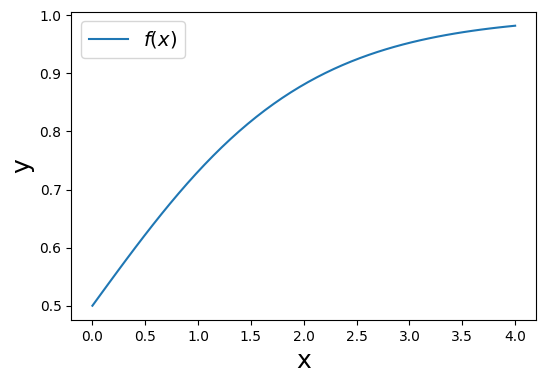

In [46]:
plt.figure(figsize=[6, 4])
x = np.linspace(0, 4, 50)  # x ranges from 0 to 4
y = [f_x(i) for i in x] # outputs

plt.plot(x, y, label="$f(x)$")

plt.xlabel("x", size=18)
plt.ylabel("y", size=18)
plt.legend(prop={"size": 14})

## Sampling   
toy example

In [47]:
# For simlicity, we use normal distribution for p(x) and q(x)
def distribution(mu=0, sigma=1):
    # return probability given a value
    distribution = stats.norm(mu, sigma)
    return distribution

In [48]:
# pre-setting p and q
n = 1000

mu_target = 3.5     # mean for p(x)
sigma_target = 1    # std for p(x)
mu_appro = 3        # mean for q(x)
sigma_appro = 1     # std for q(x)

p_x = distribution(mu_target, sigma_target) # target distribution
q_x = distribution(mu_appro, sigma_appro) #  proposal distribution

/tmp/ipython-input-291/245957511.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([np.random.normal(mu_target, sigma_target) for _ in range(3000)], label="distribution $p(x)$") # plot p
/tmp/ipython-input-291/245957511.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([np.random.normal(mu_a

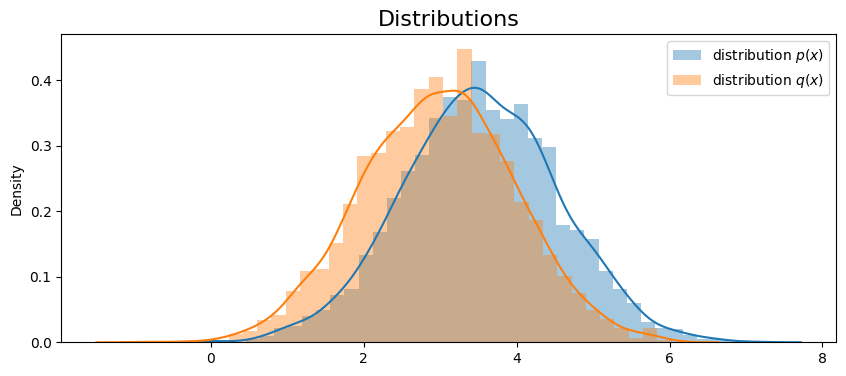

In [49]:
# Plot p and q
plt.figure(figsize=[10, 4])

sns.distplot([np.random.normal(mu_target, sigma_target) for _ in range(3000)], label="distribution $p(x)$") # plot p
sns.distplot([np.random.normal(mu_appro, sigma_appro) for _ in range(3000)], label="distribution $q(x)$") # plot q

plt.title("Distributions", size=16)
plt.legend()

directly samples from the target distribution:

$$E[f(x)] = \int f(x)p(x) dx \approx \frac{1}{n}\sum_{i} f(x_i)$$
where $ x \sim p(x)$



In [50]:
# Compute the true value sample from p(x)
s = 0
for i in range(n):
    # draw a sample
    x_i = np.random.normal(mu_target, sigma_target)
    s += f_x(x_i)
print("simulate value", s/n) # Compute the expectation value

simulate value 0.9559133304646771


Importance Sampling (giving more weight (importance) to certain samples when estimating an expectation):

$$E[f(x)] = \int f(x)p(x) dx = \int f(x)\frac{p(x)}{q(x)}q(x) dx \approx \frac{1}{n} \sum_{i} f(x_i)\frac{p(x_i)}{q(x_i)}$$

where $ x \sim q(x)$

samples are drawn from a different distribution 𝑞(𝑥)instead of 𝑝(𝑥).  
The term $\frac{p(x)}{q(x)}$ acts as a **correction factor** (importance weight) to adjust for the fact that we are sampling from $q(x)$ instead of $p(x)$.
the integral is approximated as a summation over these sampled points.

In [51]:
# calculate value sampling from distribution q [importance sampling]
value_list = [] #Importance Weighted Values
for i in range(n):
    # sample from different distribution
    x_i = np.random.normal(mu_appro, sigma_appro)
    # reweight using importance weights
    value = f_x(x_i)*(p_x.pdf(x_i) / q_x.pdf(x_i))

    value_list.append(value)
print("average {} variance {}".format(np.mean(value_list), np.var(value_list)))
# Compute the expectation value
# Estimates the expectation of f(x) under p(x) without directly sampling from p(x)
# See equations

average 0.9591102271355659 variance 0.2945033575932215


## Different $q(x)$

In [52]:
# pre-setting
n = 5000 # we need more samples to approximate the value, when distribution is dissimilar

mu_target = 3.5     # mean for p(x)
sigma_target = 1    # std for p(x)
mu_appro = 1        # mean for q(x) bad proposal
sigma_appro = 1     # std for q(x) bad proposal

p_x = distribution(mu_target, sigma_target)
q_x = distribution(mu_appro, sigma_appro) #bad proposal

/tmp/ipython-input-291/1955052219.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([np.random.normal(mu_target, sigma_target) for _ in range(3000)], label="distribution $p(x)$")
/tmp/ipython-input-291/1955052219.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([np.random.normal(mu_appro, s

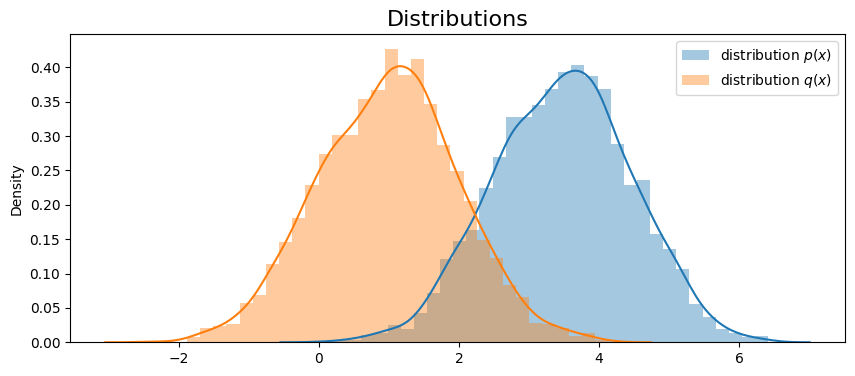

In [53]:
plt.figure(figsize=[10, 4])

sns.distplot([np.random.normal(mu_target, sigma_target) for _ in range(3000)], label="distribution $p(x)$")
sns.distplot([np.random.normal(mu_appro, sigma_appro) for _ in range(3000)], label="distribution $q(x)$")

plt.title("Distributions", size=16)
plt.legend()

In [54]:
# calculate value sampling from a different distribution q
value_list = []
# need larger steps
for i in range(n):
    # sample from q
    x_i = np.random.normal(mu_appro, sigma_appro)
    value = f_x(x_i)*(p_x.pdf(x_i) / q_x.pdf(x_i))

    value_list.append(value)

print("average {} variance {}".format(np.mean(value_list), np.var(value_list)))

average 0.8917167303928494 variance 55.539912998666544


# Rejection Sampling

In [55]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# Define target distribution p using a simple Gaussian mixture model.
def p(x):
    #probability density function
    return norm.pdf(x, loc=30, scale=10) + norm.pdf(x, loc=80, scale=20)

In [57]:
# Define proposal distribution q
def q(x):
    return norm.pdf(x, loc=50, scale=30)

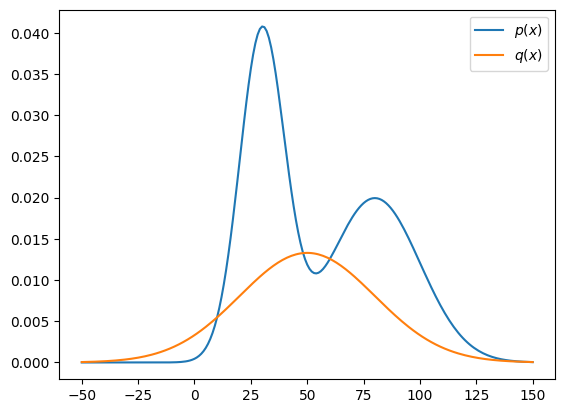

In [58]:
# Plot p and q
x = np.arange(-50, 151)
fig, ax = plt.subplots()
ax.plot(x, p(x), label=r"$p(x)$")
ax.plot(x, q(x), label=r"$q(x)$")
plt.legend()
plt.show()

In [59]:
# Define constant k
k = max(p(x) / q(x)) # Try different values for k
#better to use supremum (least upper bound)

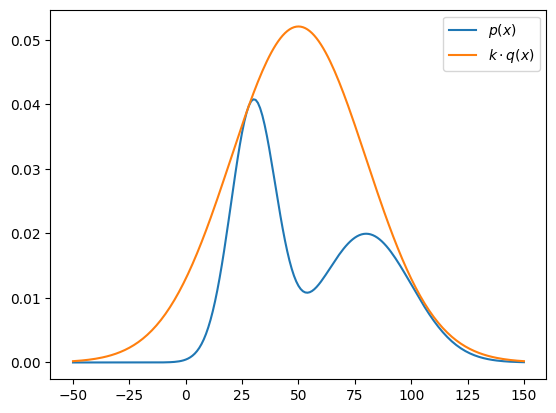

In [60]:
# Plot the scaled q distribution
fig, ax = plt.subplots()
ax.plot(x, p(x), label=r"$p(x)$")
ax.plot(x, k * q(x), label=r"$k \cdot q(x)$")
plt.legend()
plt.show()

For each sample $x_i$, we generate a uniform random number $c_i \sim U(0,1)$ and accept $x_i$ if:

$$
\frac{p(x_i)}{k q(x_i)} \geq c_i
$$



In [61]:
# Define a function for rejection sampling (hint: while loop or numpy vectorization)
def sample(size):
    xs = np.random.normal(50, 30, size=size) # Sample from q(x) xi∼q(x)
    cs = np.random.uniform(0, 1, size=size) # Uniform random numbers for rejection test
    mask = p(xs) / (k * q(xs)) >= cs # Accept-reject condition
    return xs[mask] # Return accepted samples

In [62]:
# Calculate the acceptance ratio
n_samples = 10000 # total number of samples used
accept_ratios = len(sample(n_samples))/n_samples # number of accepted samples/ total number of samples
print(accept_ratios)

0.5197


/tmp/ipython-input-291/2502309375.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample(n_samples))


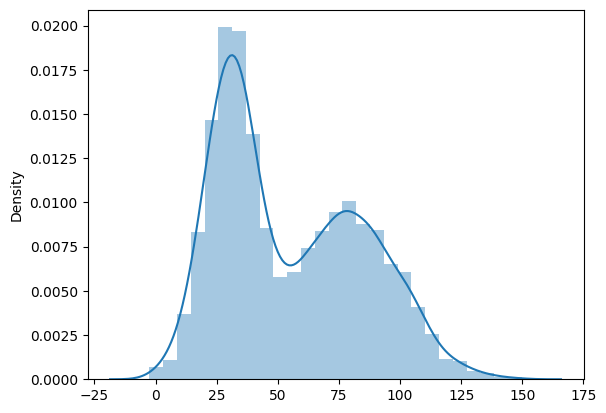

In [63]:
# Plot approximation of the target distribution
sns.distplot(sample(n_samples))
plt.show()
#should closely match the true target distribution p(x)

#MCMC

In [65]:
# NOTE: p(x) here is an unnormalized mixture (integrates to 2).
# For plotting against density=True histograms, use p(x)/2 as the normalized target pdf.
def p_pdf(x):
    return p(x) / 2.0

In [66]:
import pymc as pm
import numpy as np

# log target for MH (unnormalized is fine)
def logp_target(x):
    logp1 = pm.logp(pm.Normal.dist(mu=30.0, sigma=10.0), x)
    logp2 = pm.logp(pm.Normal.dist(mu=80.0, sigma=20.0), x)
    return pm.math.logaddexp(logp1, logp2)

draws = 20000
tune  = 2000
burn_in = tune

with pm.Model() as model:
    x_mcmc = pm.Flat("x")                 # no prior; target specified by Potential
    pm.Potential("target", logp_target(x_mcmc))

    step = pm.Metropolis()
    idata = pm.sample(draws=draws, tune=tune, step=step,
                      chains=1, cores=1, random_seed=42, progressbar=True)

mh_samples = idata.posterior["x"].values.reshape(-1)
mh_post = mh_samples[burn_in:]

print("MH post-burn-in samples:", len(mh_post))

Output()

MH post-burn-in samples: 18000


In [67]:
mh_acc = float(idata.sample_stats["accepted"].values.mean())
print("MH acceptance rate =", mh_acc)

MH acceptance rate = 0.42355


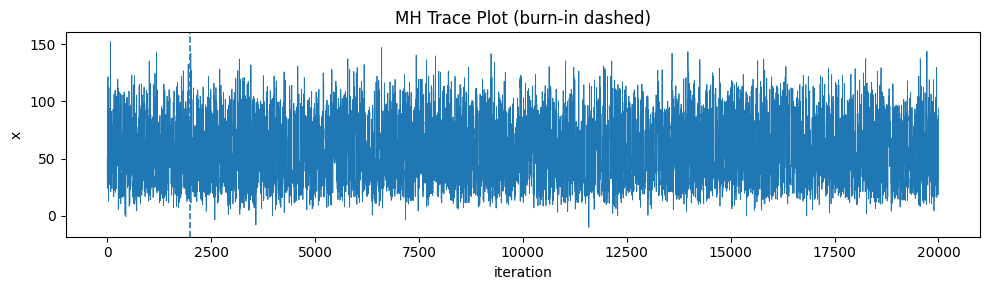

In [68]:
import matplotlib.pyplot as plt

# Trace plot
plt.figure(figsize=(10,3))
plt.plot(mh_samples, linewidth=0.6)
plt.axvline(burn_in, linestyle="--", linewidth=1.2)
plt.title("MH Trace Plot (burn-in dashed)")
plt.xlabel("iteration")
plt.ylabel("x")
plt.tight_layout()
plt.show()

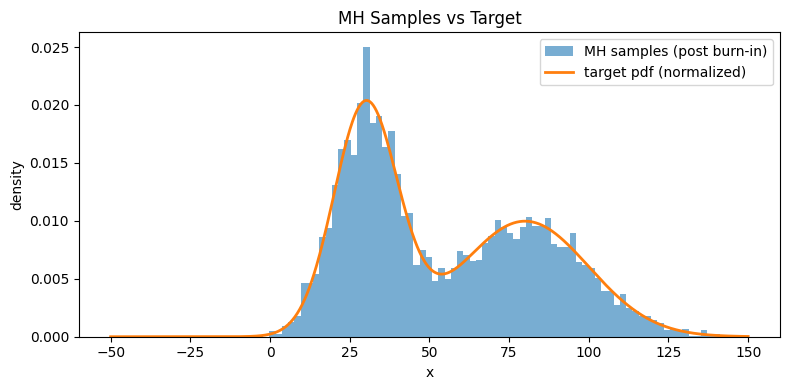

In [69]:
# Histogram vs normalized target pdf
xs = np.linspace(-50, 150, 800)
plt.figure(figsize=(8,4))
plt.hist(mh_post, bins=80, density=True, alpha=0.6, label="MH samples (post burn-in)")
plt.plot(xs, p_pdf(xs), linewidth=2.0, label="target pdf (normalized)")
plt.title("MH Samples vs Target")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# Importance sampling using the SAME proposal as your rejection sampling code
N = 10000
x_prop = np.random.normal(50, 30, size=N)  # same proposal q sampler as in RS section

# importance weights: w ∝ p(x)/q(x)
w = p(x_prop) / (q(x_prop) + 1e-300)
w = w / w.sum()

# resample to get unweighted samples for histogram comparison
idx = np.random.choice(np.arange(N), size=N, replace=True, p=w)
is_samples = x_prop[idx]

# (optional) ESS for a quick diagnostic
ess = 1.0 / np.sum(w**2)
print("IS ESS =", ess, "out of", N)

IS ESS = 7517.309892308979 out of 10000


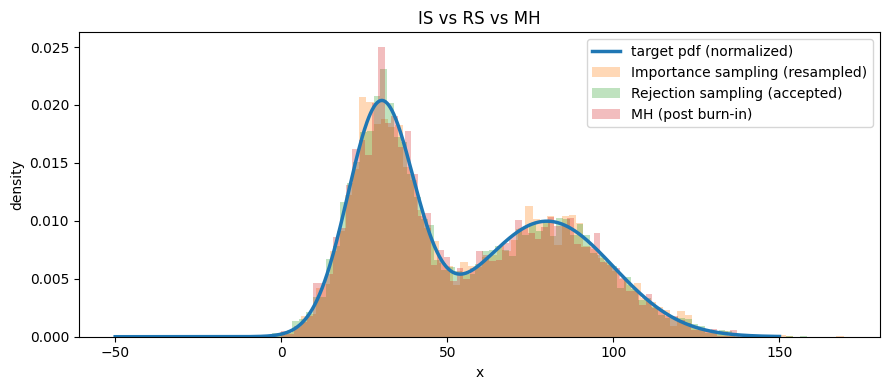

In [72]:
xs = np.linspace(-50, 150, 800)

rs_samples = sample(10000)  # your existing rejection sampler
# mh_post is your MH post-burn-in samples from the PyMC section

plt.figure(figsize=(9,4))
plt.plot(xs, p(xs)/2.0, linewidth=2.5, label="target pdf (normalized)")

plt.hist(is_samples, bins=80, density=True, alpha=0.30, label="Importance sampling (resampled)")
plt.hist(rs_samples, bins=80, density=True, alpha=0.30, label="Rejection sampling (accepted)")
plt.hist(mh_post,    bins=80, density=True, alpha=0.30, label="MH (post burn-in)")

plt.title("IS vs RS vs MH")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

| Method | Output | Pros | Main drawbacks | Key check |
|---|---|---|---|---|
| IS | estimate $E_p[f]$ (via weights) | simple, fast in low-D | weight degeneracy if $q$ misses $p$ | ESS (weights) |
| RS | i.i.d. samples $\sim p$ | exact i.i.d. samples | need envelope $kq$; low acceptance esp. high-D | acceptance rate |
| MH (MCMC) | samples $\sim p$ (correlated) | no $k$; no normalizing const | burn-in + autocorr; mixing/tuning | trace + acc. rate |